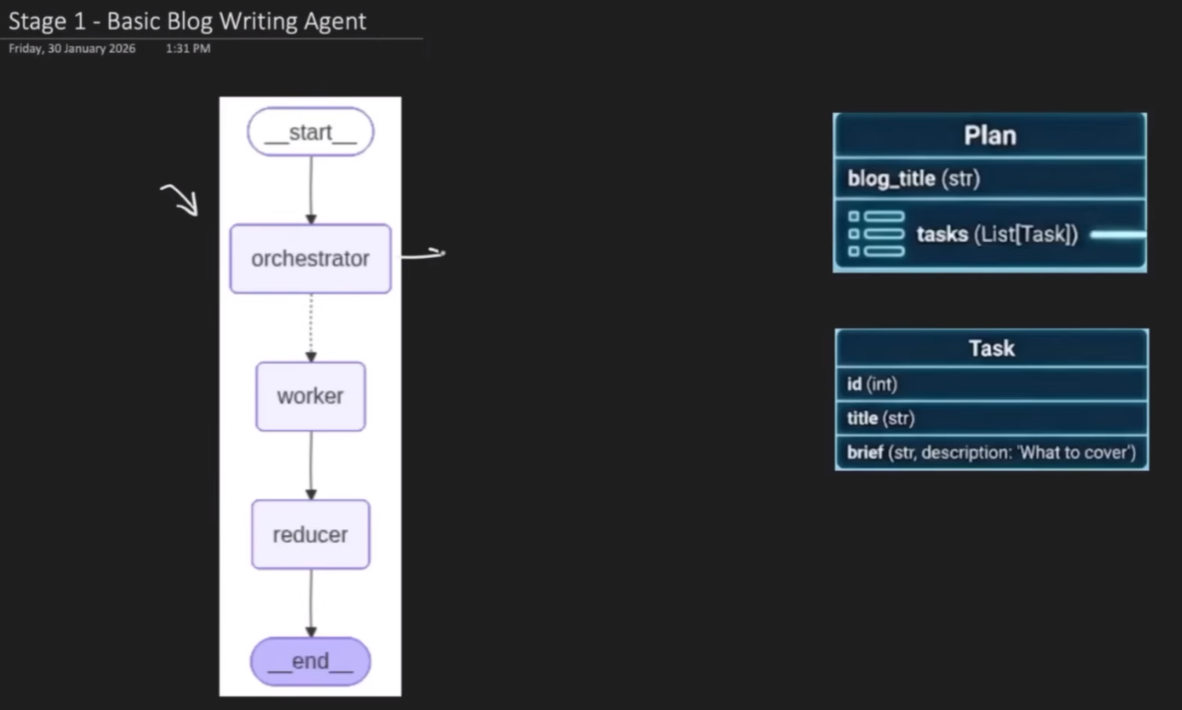

#### Architecture
1. Get a topic ("Self Attention is the topic) and it will reach to the orchestrator.
2. Orchestrator will create a plan arund the topic. We will have a plan pydantic object.
3. It will contain blog title and list of tasks i.e. task1 , task2, ..
4. Every task object will be a pydantic model. (ID(int), Title(str), brief(description:what to cover))
5. Every task will contain information for 1 section of the blog.
6. If orchestrator decides to create 5 sections then each section will create one TASK.
7. Now the plan reaches to WORKER NODE. Here we will use a mechanism called orchestrator worker flow. So if orchestrator decided to create 5 sections then dynamially worker node will fan out in 5 worker nodes, one for each section.
9. Each worker node will write about that section independently.
10. After workder node is done writing blogs for each section, REDUCER node will stitch the information and create a markdown file.


In [14]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [15]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [16]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [17]:
class State(TypedDict):
    topic: str #given by user
    plan: Plan #made by orchestrator
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add] #concat the sections
    final: str #final blog after merging

In [18]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [19]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

below fanout function will check number of tasks, based on that it will trigger worker node for each task. LangGraph gives you a method SEND to do this.

In [20]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [21]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [22]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [23]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

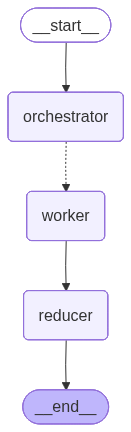

In [24]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [25]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [26]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Backbone of Modern Deep Learning', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain the concept of self-attention and why it is important in deep learning models, especially in NLP.'), Task(id=2, title='How Self-Attention Works', brief='Describe the mechanism of self-attention, including queries, keys, values, and how attention scores are computed.'), Task(id=3, title='Self-Attention vs. Traditional Attention', brief='Compare self-attention with traditional attention mechanisms and highlight their differences and benefits.'), Task(id=4, title='Role of Self-Attention in Transformers', brief='Discuss how self-attention is used in Transformer architectures and its impact on performance and efficiency.'), Task(id=5, title='Applications of Self-Attention', brief='Explore various applications of self-attention beyond NLP, such as in computer vision and other domains